# MNIST data overview

Inspect the prepared MNIST input used by this project: split sizes, class
balance, sample images, class means, and pixel values. Run the cells from top
to bottom with the project's `.venv` kernel, from the project root or `notebooks/`.

This notebook reads the existing `MNIST_DATASET` configured in
`experiment_settings.py`. It performs no download, training, or file export.
The saved images have already been normalized and resized; they are not the
original 28 x 28 MNIST images. Image dimensions come from the saved metadata.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "experiment_settings.py").is_file() and (path / "src/hnn2").is_dir()
)
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "src"))

from experiment_settings import MNIST_DATASET
from hnn2.data import load_dataset

DATASET_PATH = Path(MNIST_DATASET)
EXAMPLE_SEED = 0

## 1. Load and summarize the saved splits

`small` is the model input resolution; `big` is the raw-pixel baseline
resolution. Both contain the same images in the same row order within each
split. The sampled `test` split is drawn from `test_full`, so these are
overlapping evaluation sets and should not be combined.

Pixel statistics below use every value in each saved array. `zero_fraction`
counts exact zeros after resizing.

In [2]:
# Require an explicitly prepared dataset; this notebook does not create input.
if not DATASET_PATH.is_file():
    raise FileNotFoundError(
        f"Prepared MNIST is missing: {DATASET_PATH}. "
        "Prepare it explicitly with scripts/make_dataset.py first."
    )

# Load arrays together with their recorded source metadata.
dataset = load_dataset(DATASET_PATH)
arrays = dataset.arrays
params = dataset.source["metadata"]["params"]

# Recover image dimensions from metadata instead of hard-coding them.
image_shapes = {
    "small": tuple(params["image_size"]),
    "big": tuple(params["raw_baseline_size"]),
}

splits = ("train", "val", "test", "test_full")
digits = np.arange(10)

In [3]:
# Check labels, image dimensions, and pixel ranges for every saved split.
rows = []

for split in splits:
    labels = arrays[f"y_{split}"]

    # MNIST labels must be one-dimensional integers in the digit range.
    if labels.ndim != 1 or not np.isin(labels, digits).all():
        raise ValueError(f"Invalid MNIST labels in {split}")

    for resolution, shape in image_shapes.items():
        pixels = arrays[f"x_{split}_{resolution}"]
        expected_shape = (len(labels), int(np.prod(shape)))

        # Each flattened image must match its metadata and label count.
        if pixels.shape != expected_shape:
            raise ValueError(
                "Image shape does not match metadata or labels: "
                f"{split}/{resolution}"
            )

        # Prepared pixels must contain finite values normalized to [0, 1].
        if (
            not np.isfinite(pixels).all()
            or not (0 <= pixels.min() <= pixels.max() <= 1)
        ):
            raise ValueError(
                f"Expected finite pixel values in [0, 1]: "
                f"{split}/{resolution}"
            )

        rows.append({
            "split": split,
            "resolution": resolution,
            "samples": len(labels),
            "image_shape": f"{shape[0]} x {shape[1]}",
            "dtype": str(pixels.dtype),
            "min": pixels.min(),
            "max": pixels.max(),
            "mean": pixels.mean(dtype=np.float64),
            "std": pixels.std(dtype=np.float64),
            "zero_fraction": (pixels == 0).mean(),
        })

# Show the input identity and descriptive statistics used by later figures.
summary = pd.DataFrame(rows)

print(f"Dataset: {DATASET_PATH.name}")
print(f"SHA-256: {dataset.source['sha256']}")
display(summary.round(4))

Dataset: mnist_seed-0.npz
SHA-256: d00f4244c9437f99ea96303bd3fffaa695162d636b776f980bb7954916ddad1a


,split,resolution,samples,image_shape,dtype,min,max,mean,std,zero_fraction
0,train,small,1024,10 x 10,float32,0.0,0.9964,0.1306,0.2414,0.2935
1,train,big,1024,22 x 22,float32,0.0,1.0000,0.1306,0.2892,0.6227
2,val,small,1024,10 x 10,float32,0.0,0.9938,0.1313,0.2420,0.2939
3,val,big,1024,22 x 22,float32,0.0,1.0000,0.1314,0.2900,0.6218
4,test,small,1024,10 x 10,float32,0.0,0.9986,0.1317,0.2431,0.2944
5,test,big,1024,22 x 22,float32,0.0,1.0000,0.1317,0.2906,0.6219
6,test_full,small,10000,10 x 10,float32,0.0,1.0000,0.1325,0.2445,0.2950
7,test_full,big,10000,22 x 22,float32,0.0,1.0000,0.1326,0.2920,0.6219


## 2. Class balance

The table shows counts. The plot compares proportions so the full test set
and the smaller sampled splits can be viewed on the same scale.

In [4]:
# Count each digit in every split using a fixed 0-9 index.
class_counts = pd.DataFrame(
    {
        split: np.bincount(
            arrays[f"y_{split}"],
            minlength=len(digits),
        )
        for split in splits
    },
    index=pd.Index(digits, name="digit"),
)

display(class_counts)

# Normalize each split independently for comparison across different split sizes.
class_fractions = class_counts.div(
    class_counts.sum(axis=0),
    axis="columns",
)

,train,val,test,test_full
digit,,,,
0,101,104,100,980
1,115,117,116,1135
2,102,96,106,1032
3,105,100,104,1010
4,100,97,101,982
5,93,92,91,892
6,101,103,98,958
7,107,108,105,1028
8,99,104,100,974


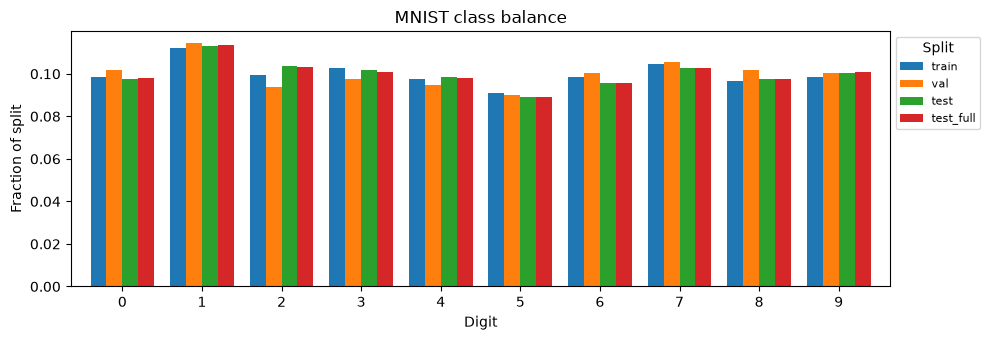

In [5]:
# Compare class proportions rather than raw counts across dataset splits.
ax = class_fractions.plot.bar(
    figsize=(10, 3.5),
    width=0.8,
    rot=0,
)

ax.set(
    xlabel="Digit",
    ylabel="Fraction of split",
    title="MNIST class balance",
)
ax.legend(
    title="Split",
    loc="upper left",
    bbox_to_anchor=(1, 1),
    fontsize=8,
)

# Finish the layout before displaying the figure in the notebook.
fig = ax.figure
fig.tight_layout()
display(fig)
plt.close(fig)

## 3. One training example per digit

A local random generator makes the selection reproducible. Both rows use
the same sample indices, with a shared grayscale range of 0 to 1. Each
column title records the row index within the saved training split.

In [6]:
# Select examples reproducibly without changing the experiment RNG streams.
rng = np.random.default_rng(EXAMPLE_SEED)
train_labels = arrays["y_train"]
example_indices = []

for digit in digits:
    candidates = np.flatnonzero(train_labels == digit)

    # Every digit must have at least one example in the training split.
    if not len(candidates):
        raise ValueError(f"No training example for digit {digit}")

    example_indices.append(int(rng.choice(candidates)))

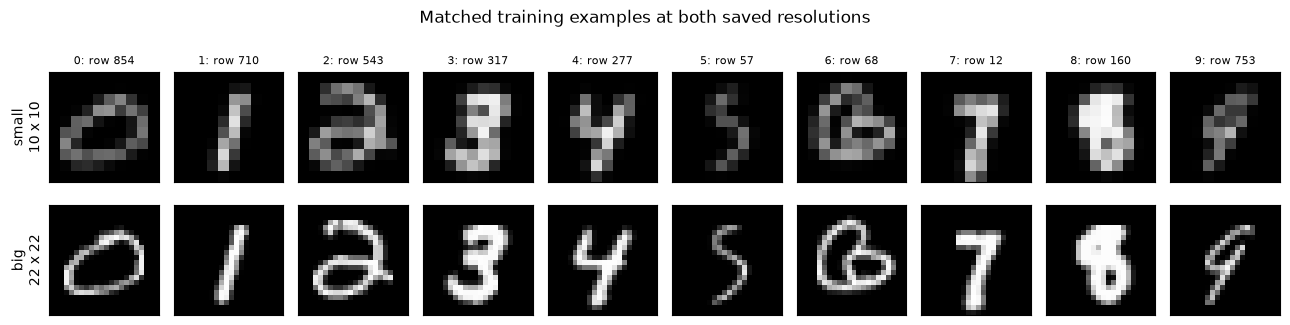

In [7]:
# Use the same sample indices in both rows for direct visual comparison.
fig, axes = plt.subplots(
    2,
    10,
    figsize=(13, 3.5),
)

for row, (resolution, shape) in enumerate(image_shapes.items()):
    # Restore image axes only for display; saved arrays remain flattened.
    images = (
        arrays[f"x_train_{resolution}"][example_indices]
        .reshape(-1, *shape)
    )

    for col, (digit, index, image) in enumerate(
        zip(digits, example_indices, images)
    ):
        ax = axes[row, col]
        ax.imshow(
            image,
            cmap="gray",
            vmin=0,
            vmax=1,
            interpolation="nearest",
        )
        ax.set(xticks=[], yticks=[])

        # Show digit and source row once, above the first resolution.
        if row == 0:
            ax.set_title(f"{digit}: row {index}", fontsize=8)

        # Label each resolution once at the left edge.
        if col == 0:
            ax.set_ylabel(
                f"{resolution}\n{shape[0]} x {shape[1]}"
            )

fig.suptitle("Matched training examples at both saved resolutions")
fig.tight_layout()
display(fig)
plt.close(fig)

## 4. Mean training image per digit

Average all training images of each class at the model input resolution.
Each title gives the number of images contributing to that mean. All panels
use the same grayscale range; individual panels are not rescaled.

In [8]:
# Restore the small training images to their two-dimensional shape.
train_labels = arrays["y_train"]
train_images = arrays["x_train_small"].reshape(
    -1,
    *image_shapes["small"],
)

# Compute one mean image and sample count for each digit.
class_mean_images = {}
class_image_counts = {}

for digit in digits:
    class_images = train_images[train_labels == digit]
    class_mean_images[digit] = class_images.mean(axis=0)
    class_image_counts[digit] = len(class_images)

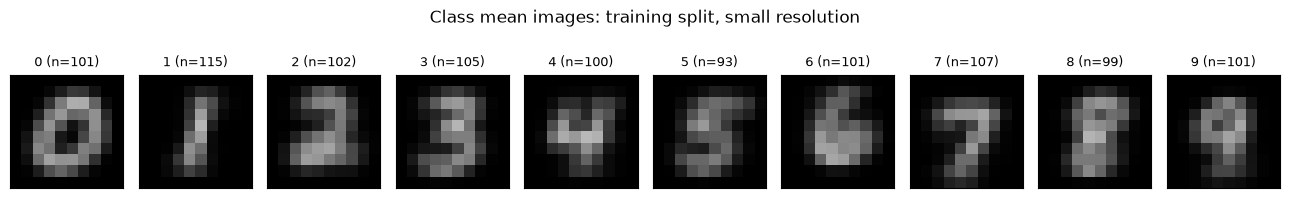

In [9]:
# Display the average spatial pattern for each digit.
fig, axes = plt.subplots(
    1,
    10,
    figsize=(13, 2.2),
)

for ax, digit in zip(axes, digits):
    ax.imshow(
        class_mean_images[digit],
        cmap="gray",
        vmin=0,
        vmax=1,
        interpolation="nearest",
    )
    ax.set(
        title=f"{digit} (n={class_image_counts[digit]})",
        xticks=[],
        yticks=[],
    )
    ax.title.set_fontsize(9)

fig.suptitle("Class mean images: training split, small resolution")
fig.tight_layout()
display(fig)
plt.close(fig)

## 5. Pixel-value distributions

Compare the sampled splits at the model input resolution. The left panel
pools all pixels; the right panel gives one mean brightness value per image.
Shared bins and density normalization make the splits comparable: histogram
area is one, and the vertical axis is density rather than counts.

In [10]:
# Compare the three equally processed evaluation splits.
distribution_splits = ("train", "val", "test")
bins = np.linspace(0, 1, 41)

pixel_values = {}
mean_brightness = {}

for split in distribution_splits:
    pixels = arrays[f"x_{split}_small"]

    # Keep individual pixels and per-image means as separate distributions.
    pixel_values[split] = pixels.ravel()
    mean_brightness[split] = pixels.mean(axis=1)

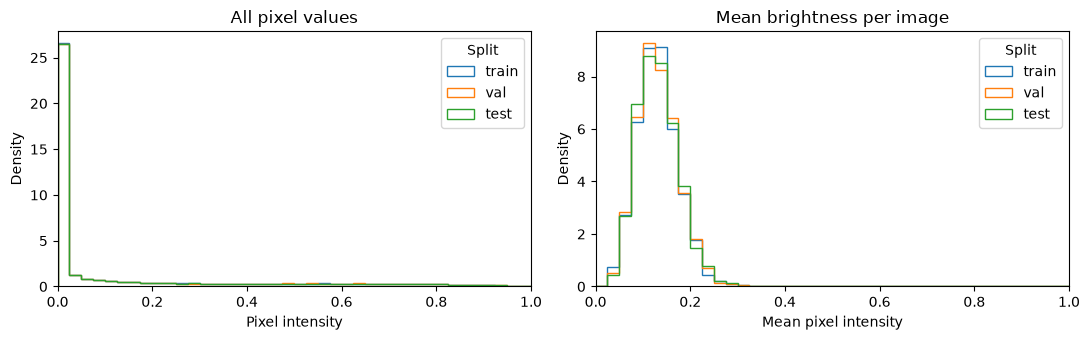

In [11]:
# Use density-normalized step histograms to compare splits of any size.
fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 3.5),
)

for split in distribution_splits:
    axes[0].hist(
        pixel_values[split],
        bins=bins,
        density=True,
        histtype="step",
        label=split,
    )
    axes[1].hist(
        mean_brightness[split],
        bins=bins,
        density=True,
        histtype="step",
        label=split,
    )

# Apply consistent axes and legends to both distributions.
for ax, title, xlabel in zip(
    axes,
    ("All pixel values", "Mean brightness per image"),
    ("Pixel intensity", "Mean pixel intensity"),
):
    ax.set(
        title=title,
        xlabel=xlabel,
        ylabel="Density",
        xlim=(0, 1),
    )
    ax.legend(title="Split")

fig.tight_layout()
display(fig)
plt.close(fig)